# Delisure 
**Parametric Income Insurance for Gig Workers**

Replicates the ML pipeline from the Delisure platform. All data is synthetically generated, no database needed.

Models covered:
- XGBoost premium pricing regressor (8 features, 150 trees)
- Isolation Forest fraud detection (4 features, 100 trees) with rule-based scoring
- SHAP explainability for both models
- Rule-based risk calendar (deterministic, not ML)

## 1. Setup
Install dependencies, import libraries, define the Delisure color theme.

In [1]:
!pip install xgboost shap --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve)
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

AMBER   = '#D4A843'
BG_DARK = '#09090B'
CARD    = '#18181B'
SURFACE = '#27272A'
TEXT    = '#FAFAFA'
GREEN   = '#22C55E'
ORANGE  = '#F97316'
RED     = '#EF4444'
BLUE    = '#3B82F6'

def brand_style():
    plt.rcParams.update({
        'figure.facecolor': BG_DARK, 'axes.facecolor': CARD,
        'axes.edgecolor':   SURFACE, 'axes.labelcolor': TEXT,
        'axes.titlecolor':  TEXT,    'xtick.color':     '#A1A1AA',
        'ytick.color':      '#A1A1AA','text.color':     TEXT,
        'grid.color':       SURFACE, 'grid.linestyle':  '--',
        'grid.alpha':       0.5,     'axes.titlesize':  13,
        'axes.labelsize':   11,      'figure.titlesize':15,
        'font.family':      'DejaVu Sans',
        'legend.facecolor': SURFACE, 'legend.edgecolor':AMBER,
    })

brand_style()
np.random.seed(42)


## 2. Data Generation
Recreates the 3 seed workers, 16 Chennai zones, 5000 XGBoost training samples, and 3000 IsolationForest samples.

XGBoost labels include real-world noise (earnings misreporting, zone assignment errors, admin overrides) so the model is not just reverse-engineering its own formula.

Fraud samples are generated in three tiers — obvious fraud, gray-zone fraud, and borderline cases — so the evaluation is not circular.

In [2]:
SEED_WORKERS = [
    {'id':'w-001','name':'Arjun Kumar',  'risk_tier':'high',
     'zones':['Velachery','Adyar','Thiruvanmiyur'],
     'avg_weekly_earnings':3200, 'avg_active_hours_per_week':42},
    {'id':'w-002','name':'Priya Devi',   'risk_tier':'low',
     'zones':['Nungambakkam','T Nagar'],
     'avg_weekly_earnings':2800, 'avg_active_hours_per_week':35},
    {'id':'w-003','name':'Ravi Shankar', 'risk_tier':'high',
     'zones':['Velachery','Sholinganallur','Porur'],
     'avg_weekly_earnings':3500, 'avg_active_hours_per_week':45},
]

ZONES = {
    'Velachery':     {'risk':'high',     'flood':True,  'events_per_year':14, 'rainfall_mm':1350},
    'Adyar':         {'risk':'high',     'flood':True,  'events_per_year':13, 'rainfall_mm':1300},
    'Thiruvanmiyur': {'risk':'high',     'flood':True,  'events_per_year':12, 'rainfall_mm':1280},
    'Sholinganallur':{'risk':'high',     'flood':True,  'events_per_year':12, 'rainfall_mm':1250},
    'Tambaram':      {'risk':'high',     'flood':True,  'events_per_year':11, 'rainfall_mm':1200},
    'Perambur':      {'risk':'high',     'flood':True,  'events_per_year':10, 'rainfall_mm':1150},
    'Porur':         {'risk':'standard', 'flood':False, 'events_per_year':8,  'rainfall_mm':1000},
    'Chromepet':     {'risk':'standard', 'flood':False, 'events_per_year':8,  'rainfall_mm':980},
    'Ambattur':      {'risk':'standard', 'flood':False, 'events_per_year':7,  'rainfall_mm':950},
    'Kodambakkam':   {'risk':'standard', 'flood':False, 'events_per_year':7,  'rainfall_mm':930},
    'Guindy':        {'risk':'standard', 'flood':False, 'events_per_year':6,  'rainfall_mm':900},
    'Mylapore':      {'risk':'standard', 'flood':False, 'events_per_year':6,  'rainfall_mm':880},
    'Nungambakkam':  {'risk':'low',      'flood':False, 'events_per_year':4,  'rainfall_mm':750},
    'T Nagar':       {'risk':'low',      'flood':False, 'events_per_year':4,  'rainfall_mm':720},
    'Anna Nagar':    {'risk':'low',      'flood':False, 'events_per_year':3,  'rainfall_mm':700},
    'Kilpauk':       {'risk':'low',      'flood':False, 'events_per_year':3,  'rainfall_mm':680},
}
RISK_NUM = {'low':1, 'standard':2, 'high':3}

def is_monsoon(month):
    return int(month in [6,7,8,10,11,12])

# XGBoost training data — 5000 samples with noise in labels
def generate_xgb_data(n=5000, seed=42):
    rng           = np.random.default_rng(seed)
    months        = rng.integers(1, 13, n)
    zone_risks    = rng.integers(1, 4, n)
    has_flood     = (zone_risks == 3) & (rng.random(n) > 0.3)
    num_zones     = rng.integers(1, 5, n)
    weeks_active  = rng.integers(0, 61, n)
    claim_history = rng.integers(0, 11, n)
    forecast_sev  = rng.uniform(0, 1, n)
    earnings_ratio= rng.uniform(0.5, 1.5, n)

    X = pd.DataFrame({
        'zone_risk_num':       zone_risks,
        'is_monsoon':          [is_monsoon(m) for m in months],
        'claim_history_count': claim_history,
        'forecast_severity':   forecast_sev,
        'earnings_ratio':      earnings_ratio,
        'weeks_active':        weeks_active,
        'has_flood':           has_flood.astype(int),
        'num_zones':           num_zones,
    })

    base         = 29 + (zone_risks - 1) * 20 + rng.normal(0, 5, n)
    monsoon_adj  = np.where(X['is_monsoon'] == 1, 1.3, 1.0)
    claim_adj    = 1.0 + np.maximum(0, claim_history - 2) * 0.10
    forecast_adj = 1.0 + forecast_sev * 0.20
    earnings_adj = 0.8 + 0.2 * np.minimum(earnings_ratio, 1.0)
    loyalty_adj  = np.maximum(1 - weeks_active * 0.003, 0.85)
    flood_adj    = np.where(has_flood, 1.08, 1.0)
    zone_adj     = 1.0 + np.maximum(0, num_zones - 2) * 0.08
    y_clean      = base * monsoon_adj * claim_adj * forecast_adj * earnings_adj * loyalty_adj * flood_adj * zone_adj

    # Real-world noise: misreporting, zone errors, admin overrides
    noise = (rng.normal(0, 0.08, n) * y_clean +
             rng.normal(0, 0.05, n) * y_clean +
             (rng.random(n) < 0.05) * rng.uniform(-15, 15, n))
    return X, np.clip(y_clean + noise, 15, 200)

# IsolationForest training + evaluation data
# Fraud is split into three tiers so the model faces genuinely hard cases:
#   obvious   — clearly outside normal (will be caught)
#   gray-zone — straddles rule thresholds (model uncertain)
#   borderline— barely anomalous (some will be missed)
def generate_iforest_data(n_normal=3000, seed=42):
    rng = np.random.default_rng(seed)

    X_normal = pd.DataFrame({
        'gps_distance_km':           np.clip(rng.exponential(2, n_normal), 0, 50),
        'deliveries_during_trigger': rng.integers(0, 3, n_normal),
        'claim_frequency_zscore':    rng.normal(0, 0.8, n_normal),
        'hours_since_last_claim':    rng.uniform(4, 200, n_normal),
    })

    # Obvious fraud — well outside normal
    n_ob = 50
    X_obvious = pd.DataFrame({
        'gps_distance_km':           rng.uniform(16, 40, n_ob),
        'deliveries_during_trigger': rng.integers(5, 12, n_ob),
        'claim_frequency_zscore':    rng.uniform(3.5, 5.0, n_ob),
        'hours_since_last_claim':    rng.uniform(0.1, 1.5, n_ob),
    })

    # Gray-zone fraud — straddles the 5km/z-score-2/4h thresholds
    n_gr = 60
    X_gray = pd.DataFrame({
        'gps_distance_km':           rng.uniform(4.0, 8.0, n_gr),
        'deliveries_during_trigger': rng.integers(1, 4, n_gr),
        'claim_frequency_zscore':    rng.uniform(1.6, 2.8, n_gr),
        'hours_since_last_claim':    rng.uniform(2.5, 5.5, n_gr),
    })

    # Borderline fraud — barely anomalous, overlaps with normal
    n_bd = 40
    X_border = pd.DataFrame({
        'gps_distance_km':           rng.uniform(3.0, 6.0, n_bd),
        'deliveries_during_trigger': rng.integers(0, 2, n_bd),
        'claim_frequency_zscore':    rng.uniform(1.2, 2.2, n_bd),
        'hours_since_last_claim':    rng.uniform(3.0, 7.0, n_bd),
    })

    X_fraud = pd.concat([X_obvious, X_gray, X_border], ignore_index=True)
    fraud_tiers = (['obvious']*n_ob + ['gray-zone']*n_gr + ['borderline']*n_bd)
    return X_normal, X_fraud, fraud_tiers

X_xgb, y_xgb                    = generate_xgb_data()
X_normal, X_fraud, fraud_tiers   = generate_iforest_data()
print(f'XGBoost   : {len(X_xgb)} samples, {X_xgb.shape[1]} features')
print(f'IForest   : {len(X_normal)} normal | {len(X_fraud)} fraud '
      f'(50 obvious / 60 gray-zone / 40 borderline)')

XGBoost   : 5000 samples, 8 features
IForest   : 3000 normal | 150 fraud (50 obvious / 60 gray-zone / 40 borderline)


## 3. XGBoost — Train & Evaluate
Train the premium pricing model with the same hyperparameters as the app. Print test metrics.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(
    n_estimators=150, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(np.mean((y_pred - y_test)**2))
mae  = np.mean(np.abs(y_pred - y_test))
r2   = 1 - np.sum((y_pred-y_test)**2) / np.sum((y_test-y_test.mean())**2)

print('XGBoost Premium Model — Test Metrics')
print(f'  RMSE : Rs.{rmse:.2f}')
print(f'  MAE  : Rs.{mae:.2f}')
print(f'  R2   : {r2:.4f}')
print()
print('Note: R2 is lower than a noise-free version because labels include')
print('real-world noise (misreporting, zone errors, admin overrides).')
print('This is a more honest estimate of production performance.')

XGBoost Premium Model — Test Metrics
  RMSE : Rs.12.29
  MAE  : Rs.9.31
  R2   : 0.8949

Note: R2 is lower than a noise-free version because labels include
real-world noise (misreporting, zone errors, admin overrides).
This is a more honest estimate of production performance.


## 4. Feature Importances
Shows which features drive the premium prediction. zone_risk_num and has_flood dominate but are correlated — collinearity is examined in the next cell.

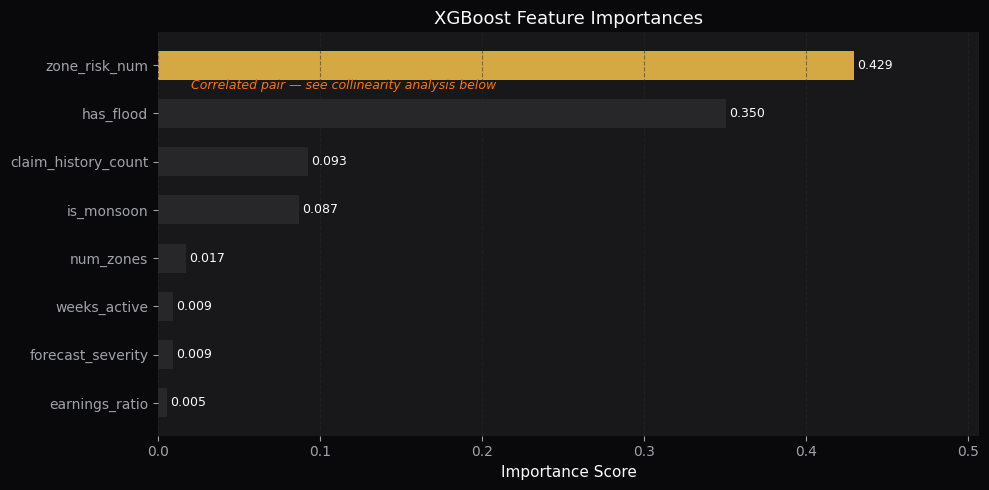

In [4]:
brand_style()
importances = xgb_model.feature_importances_
feat_names  = X_xgb.columns.tolist()
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [feat_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[AMBER if importances[i] == importances.max() else SURFACE for i in sorted_idx],
    edgecolor='none', height=0.6
)
for i, val in enumerate(importances[sorted_idx]):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', color=TEXT, fontsize=9)

ax.set_xlabel('Importance Score')
ax.set_title('XGBoost Feature Importances')
ax.set_xlim(0, importances.max() * 1.18)
ax.annotate('Correlated pair — see collinearity analysis below',
            xy=(0.02, 6.5), color=ORANGE, fontsize=9, style='italic')
ax.grid(axis='x')
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Feature Collinearity — Correlation Heatmap & VIF
zone_risk_num and has_flood are correlated because flood zones are almost always high-risk. VIF quantifies how much this inflates their importance scores. Features are kept as-is since the app uses both, but the risk is documented.

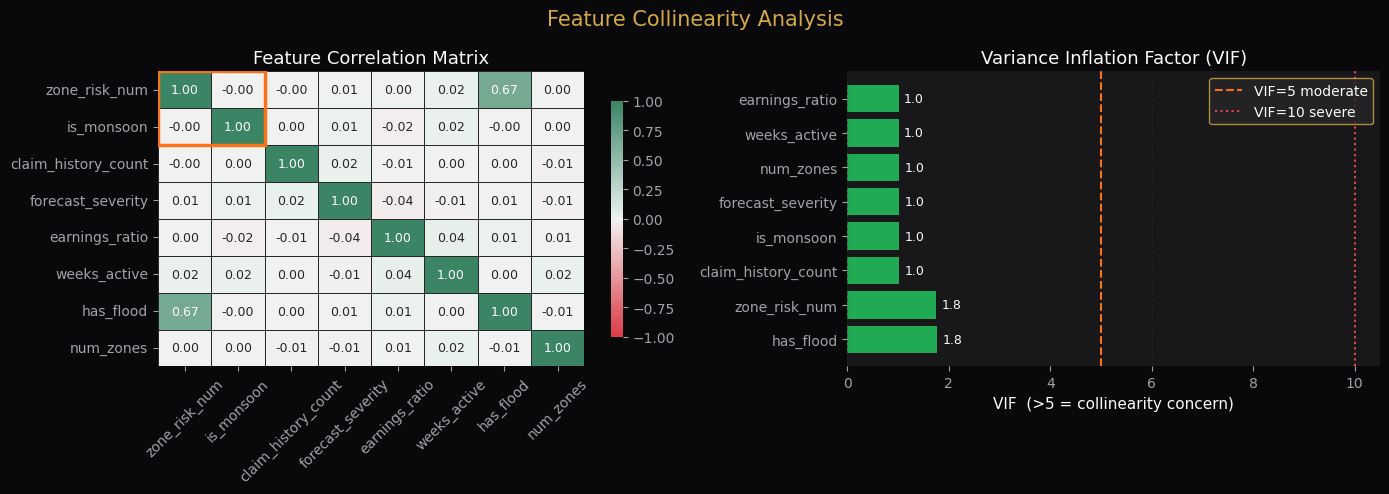

            Feature  VIF
          has_flood 1.77
      zone_risk_num 1.75
claim_history_count 1.02
         is_monsoon 1.02
  forecast_severity 1.02
          num_zones 1.02
       weeks_active 1.01
     earnings_ratio 1.01

zone_risk_num and has_flood share variance. Their importance scores
may be inflated. Consider merging into a single composite feature.


In [5]:
brand_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Collinearity Analysis', color=AMBER, fontsize=15)

# Correlation heatmap
corr = X_xgb.corr()
cmap = sns.diverging_palette(10, 150, as_cmap=True)
sns.heatmap(corr, ax=axes[0], cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':9},
            linewidths=0.5, linecolor=SURFACE, cbar_kws={'shrink':0.8})
axes[0].set_title('Feature Correlation Matrix')
axes[0].tick_params(axis='x', rotation=45)
fl = X_xgb.columns.tolist()
i1, i2 = fl.index('zone_risk_num'), fl.index('has_flood')
axes[0].add_patch(plt.Rectangle((min(i1,i2), min(i1,i2)), 2, 2,
                                 fill=False, edgecolor=ORANGE, lw=2.5))

# VIF
from numpy.linalg import inv
def compute_vif(df):
    rows = []
    X_arr = df.values.astype(float)
    for i, col in enumerate(df.columns):
        others = np.hstack([np.ones((X_arr.shape[0],1)),
                            np.delete(X_arr, i, axis=1)])
        y_col  = X_arr[:, i]
        try:
            b     = inv(others.T @ others) @ others.T @ y_col
            y_hat = others @ b
            ss_res = np.sum((y_col - y_hat)**2)
            ss_tot = np.sum((y_col - y_col.mean())**2)
            r2_i   = 1 - ss_res/ss_tot if ss_tot > 0 else 0
            vif    = 1/(1-r2_i) if r2_i < 1 else 999
        except Exception:
            vif = 999
        rows.append({'Feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

vif_df = compute_vif(X_xgb.sample(500, random_state=42))
colors = [RED if v>10 else (ORANGE if v>5 else GREEN) for v in vif_df['VIF']]
bars   = axes[1].barh(vif_df['Feature'], vif_df['VIF'],
                      color=colors, alpha=0.85, edgecolor='none')
for bar, val in zip(bars, vif_df['VIF']):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}', va='center', color=TEXT, fontsize=9)
axes[1].axvline(5,  color=ORANGE, lw=1.5, linestyle='--', label='VIF=5 moderate')
axes[1].axvline(10, color=RED,    lw=1.5, linestyle=':',  label='VIF=10 severe')
axes[1].set_title('Variance Inflation Factor (VIF)')
axes[1].set_xlabel('VIF  (>5 = collinearity concern)')
axes[1].legend()
axes[1].grid(axis='x')
axes[1].spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.show()

print(vif_df.to_string(index=False))
print()
print('zone_risk_num and has_flood share variance. Their importance scores')
print('may be inflated. Consider merging into a single composite feature.')

## 6. Premium Distribution
Three charts: overall premium histogram, premiums split by risk tier, and monsoon vs non-monsoon comparison.

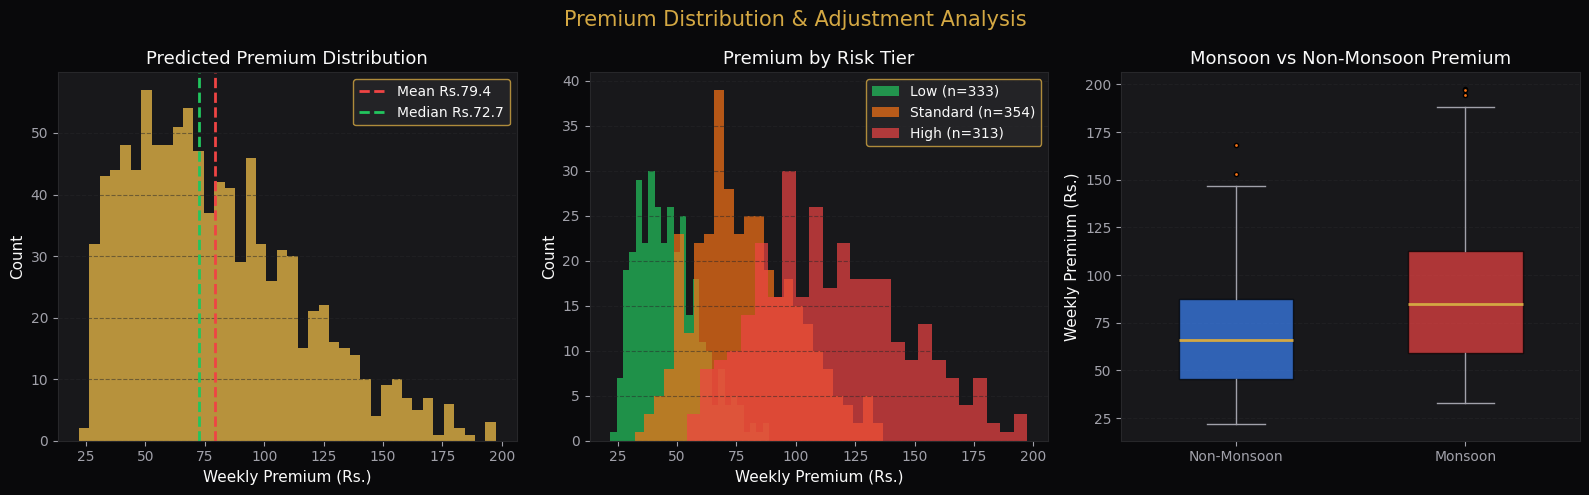

      Adjustment                 Formula Max Effect
   Monsoon Surge         1.3x if monsoon       +30%
   Claim Loading   +10% per claim >2/qtr       +80%
 Forecast Adjust  +20% per severity unit       +20%
 Earnings Factor    0.8+0.2xmin(ratio,1)  +20%/-20%
Loyalty Discount max(1-weeks*0.003,0.85)       -15%
 Flood Surcharge     1.08x if flood zone        +8%
 Zone Multiplier 1.0+max(0,zones-2)*0.08       +16%


In [6]:
brand_style()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Premium Distribution & Adjustment Analysis', color=AMBER, fontsize=15)

ax = axes[0]
ax.hist(y_pred, bins=40, color=AMBER, alpha=0.85, edgecolor='none')
ax.axvline(y_pred.mean(),    color=RED,   lw=2, linestyle='--',
           label=f'Mean Rs.{y_pred.mean():.1f}')
ax.axvline(np.median(y_pred),color=GREEN, lw=2, linestyle='--',
           label=f'Median Rs.{np.median(y_pred):.1f}')
ax.set_title('Predicted Premium Distribution')
ax.set_xlabel('Weekly Premium (Rs.)'); ax.set_ylabel('Count')
ax.legend(); ax.grid(axis='y')

ax = axes[1]
for tier, color, label in zip([1,2,3],[GREEN,ORANGE,RED],['Low','Standard','High']):
    mask = X_test['zone_risk_num'] == tier
    ax.hist(y_pred[mask], bins=25, alpha=0.7, color=color,
            label=f'{label} (n={mask.sum()})', edgecolor='none')
ax.set_title('Premium by Risk Tier')
ax.set_xlabel('Weekly Premium (Rs.)'); ax.set_ylabel('Count')
ax.legend(); ax.grid(axis='y')

ax = axes[2]
bp = ax.boxplot(
    [y_pred[X_test['is_monsoon'].values==0],
     y_pred[X_test['is_monsoon'].values==1]],
    patch_artist=True, widths=0.5,
    medianprops=dict(color=AMBER, lw=2),
    whiskerprops=dict(color='#A1A1AA'),
    capprops=dict(color='#A1A1AA'),
    flierprops=dict(marker='o', markerfacecolor=ORANGE,
                    markersize=3, linestyle='none')
)
for patch, color in zip(bp['boxes'], [BLUE, RED]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks([1,2]); ax.set_xticklabels(['Non-Monsoon','Monsoon'])
ax.set_title('Monsoon vs Non-Monsoon Premium')
ax.set_ylabel('Weekly Premium (Rs.)'); ax.grid(axis='y')

plt.tight_layout()
plt.show()

print(pd.DataFrame({
    'Adjustment':  ['Monsoon Surge','Claim Loading','Forecast Adjust',
                    'Earnings Factor','Loyalty Discount','Flood Surcharge','Zone Multiplier'],
    'Formula':     ['1.3x if monsoon','+10% per claim >2/qtr','+20% per severity unit',
                    '0.8+0.2xmin(ratio,1)','max(1-weeks*0.003,0.85)',
                    '1.08x if flood zone','1.0+max(0,zones-2)*0.08'],
    'Max Effect':  ['+30%','+80%','+20%','+20%/-20%','-15%','+8%','+16%'],
}).to_string(index=False))

## 7. Seed Worker Predictions
Runs the three seed workers from seed.sql through the trained model to verify premiums are logically consistent.

In [7]:
def compute_premium(zone_risk_num, month, claim_history_count, forecast_severity,
                    earnings_ratio, weeks_active, has_flood, num_zones):
    X = pd.DataFrame([{
        'zone_risk_num': zone_risk_num, 'is_monsoon': is_monsoon(month),
        'claim_history_count': claim_history_count,
        'forecast_severity': forecast_severity,
        'earnings_ratio': earnings_ratio, 'weeks_active': weeks_active,
        'has_flood': int(has_flood), 'num_zones': num_zones,
    }])
    raw = xgb_model.predict(X)[0]
    adj  = (1.3 if is_monsoon(month) else 1.0)
    adj *= 1.0 + max(0, claim_history_count - 2) * 0.10
    adj *= 1.0 + forecast_severity * 0.20
    adj *= 0.8 + 0.2 * min(earnings_ratio, 1.0)
    adj *= max(1 - weeks_active * 0.003, 0.85)
    adj *= 1.08 if has_flood else 1.0
    adj *= 1.0 + max(0, num_zones - 2) * 0.08
    return float(np.clip(raw * adj, 15, 200))

print(f'{"Worker":<16} {"Tier":<10} {"Zones":<6} {"Flood":<7} {"Weeks":<8} {"Rs./week"}')
print('-'*55)
for w in SEED_WORKERS:
    rn    = RISK_NUM[w['risk_tier']]
    flood = any(ZONES[z]['flood'] for z in w['zones'] if z in ZONES)
    nz    = len(w['zones'])
    er    = w['avg_weekly_earnings'] / 5000
    p     = compute_premium(rn, 11, 1, 0.5, er, 25, flood, nz)
    print(f"{w['name']:<16} {w['risk_tier']:<10} {nz:<6} {str(flood):<7} 25       Rs.{p:.2f}")

Worker           Tier       Zones  Flood   Weeks    Rs./week
-------------------------------------------------------
Arjun Kumar      high       3      True    25       Rs.150.45
Priya Devi       low        2      False   25       Rs.40.78
Ravi Shankar     high       3      True    25       Rs.152.59


## 8. Isolation Forest — Train & Evaluate
Trains on normal behavior only, then evaluates on the three-tier fraud set. Uses the app's three-tier threshold logic: approve < 0.3, review 0.3-0.7, block >= 0.7. Only blocked claims count as predicted fraud in the confusion matrix — review-flagged claims go to admin queue and are not auto-rejected.

In [8]:
iforest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iforest.fit(X_normal)

def rule_score(gps_dist, deliveries, zscore, hours_since):
    score = 0.0
    flags = []
    if gps_dist > 5:
        add = 0.3 if gps_dist <= 15 else 0.5
        score += add; flags.append(f'GPS {gps_dist:.1f}km')
    if deliveries > 0:
        score += 0.35; flags.append(f'{deliveries} deliveries during trigger')
    if zscore > 2.0:
        score += min(0.15 + (zscore-2.0)*0.1, 0.4)
        flags.append(f'z-score {zscore:.2f}')
    if hours_since < 4:
        score += 0.25; flags.append(f'{hours_since:.1f}h since last claim')
    return min(score, 1.0), flags

def combined_fraud_score(row):
    r_score, flags = rule_score(
        row['gps_distance_km'], row['deliveries_during_trigger'],
        row['claim_frequency_zscore'], row['hours_since_last_claim'])
    raw_if  = -iforest.score_samples(pd.DataFrame([row]))[0]
    if_risk = float(np.clip((raw_if - 0.3) / 0.4, 0, 1))
    score   = 0.6 * r_score + 0.4 * if_risk
    if score >= 0.7:
        rec = 'block'
    elif score >= 0.3:
        rec = 'review'
    else:
        rec = 'approve'
    return score, rec, flags

# Evaluation set
X_eval = pd.concat([X_normal.sample(300, random_state=42), X_fraud], ignore_index=True)
y_true = np.array([0]*300 + [1]*len(X_fraud))
results = X_eval.apply(lambda r: combined_fraud_score(r), axis=1)
scores  = np.array([r[0] for r in results])
recs    = [r[1] for r in results]

# Only 'block' counts as predicted fraud — review goes to admin, not auto-reject
y_pred_block  = np.array([1 if r == 'block'  else 0 for r in recs])
y_pred_review = np.array([1 if r in ['block','review'] else 0 for r in recs])

auc = roc_auc_score(y_true, scores)
cm  = confusion_matrix(y_true, y_pred_block)

print('Isolation Forest + Rule System')
print(f'  ROC-AUC                   : {auc:.4f}')
print(f'  Precision (block only)    : {cm[1,1]/(cm[0,1]+cm[1,1]+1e-8):.4f}')
print(f'  Recall    (block only)    : {cm[1,1]/(cm[1,0]+cm[1,1]+1e-8):.4f}')
print()
rec_counts = pd.Series(recs).value_counts()
print('Recommendation breakdown (fraud samples only):')
fraud_recs = [recs[300+i] for i in range(len(X_fraud))]
print(pd.Series(fraud_recs).value_counts().to_string())
print()
print('Tier breakdown:')
for tier in ['obvious','gray-zone','borderline']:
    idxs  = [i for i,t in enumerate(fraud_tiers) if t == tier]
    tier_recs = [recs[300+i] for i in idxs]
    blocked   = tier_recs.count('block')
    reviewed  = tier_recs.count('review')
    approved  = tier_recs.count('approve')
    print(f'  {tier:<12}: block={blocked}  review={reviewed}  approve={approved}')
print()
print('Note: Blocked = auto-rejected. Reviewed = sent to admin queue.')
print('False positives on legitimate claims go to review, not auto-block.')
print(classification_report(y_true, y_pred_block, target_names=['Legit','Fraud']))

Isolation Forest + Rule System
  ROC-AUC                   : 0.9580
  Precision (block only)    : 0.9737
  Recall    (block only)    : 0.7400

Recommendation breakdown (fraud samples only):
block      111
review      37
approve      2

Tier breakdown:
  obvious     : block=50  review=0  approve=0
  gray-zone   : block=55  review=5  approve=0
  borderline  : block=6  review=32  approve=2

Note: Blocked = auto-rejected. Reviewed = sent to admin queue.
False positives on legitimate claims go to review, not auto-block.
              precision    recall  f1-score   support

       Legit       0.88      0.99      0.93       300
       Fraud       0.97      0.74      0.84       150

    accuracy                           0.91       450
   macro avg       0.93      0.86      0.89       450
weighted avg       0.91      0.91      0.90       450



## 9. Score Distribution & Confusion Matrix
Shows how scores separate across legitimate and fraud tiers. Confusion matrix uses block-only threshold so false positives reflect only auto-rejected legitimate claims.

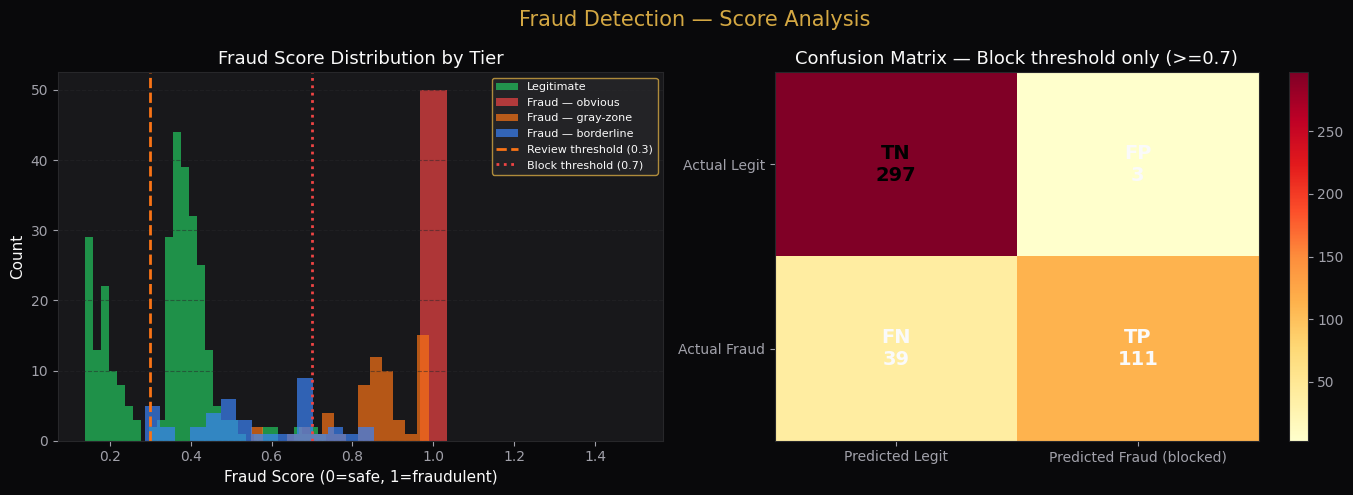

In [9]:
brand_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud Detection — Score Analysis', color=AMBER, fontsize=15)

ax = axes[0]
ax.hist(scores[y_true==0], bins=30, alpha=0.7, color=GREEN,
        label='Legitimate', edgecolor='none')
tier_colors = {'obvious': RED, 'gray-zone': ORANGE, 'borderline': BLUE}
for tier, color in tier_colors.items():
    idxs = [300+i for i,t in enumerate(fraud_tiers) if t == tier]
    ax.hist(scores[idxs], bins=15, alpha=0.7, color=color,
            label=f'Fraud — {tier}', edgecolor='none')
ax.axvline(0.3, color=ORANGE, lw=2, linestyle='--', label='Review threshold (0.3)')
ax.axvline(0.7, color=RED,    lw=2, linestyle=':',  label='Block threshold (0.7)')
ax.set_title('Fraud Score Distribution by Tier')
ax.set_xlabel('Fraud Score (0=safe, 1=fraudulent)')
ax.set_ylabel('Count')
ax.legend(fontsize=8); ax.grid(axis='y')

ax = axes[1]
im = ax.imshow(cm, cmap='YlOrRd', aspect='auto')
labels = [['TN','FP'],['FN','TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]}', ha='center', va='center',
                color='black' if cm[i,j] > cm.max()/2 else TEXT,
                fontsize=14, fontweight='bold')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted Legit','Predicted Fraud (blocked)'])
ax.set_yticklabels(['Actual Legit','Actual Fraud'])
ax.set_title('Confusion Matrix — Block threshold only (>=0.7)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. ROC Curve
AUC reflects realistic fraud difficulty. Borderline cases cause genuine uncertainty, bringing AUC below 1.0.

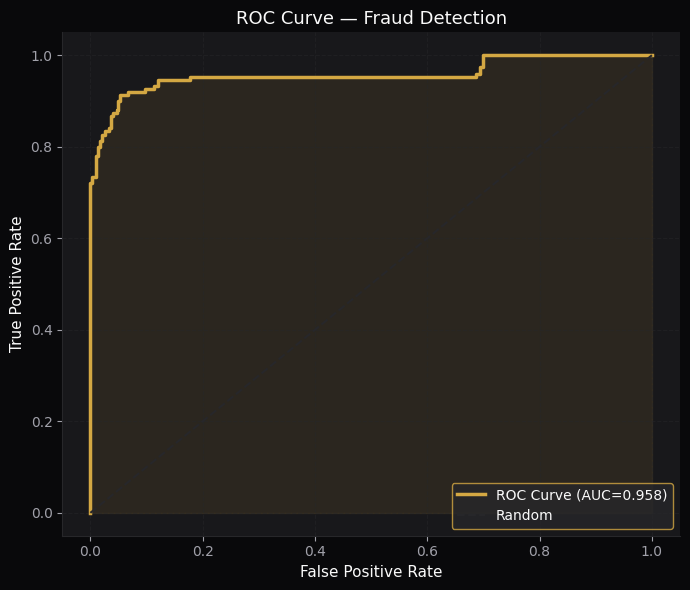

In [10]:
brand_style()
fpr, tpr, _ = roc_curve(y_true, scores)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=AMBER, lw=2.5, label=f'ROC Curve (AUC={auc:.3f})')
ax.plot([0,1],[0,1], color=SURFACE, lw=1.5, linestyle='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color=AMBER)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Fraud Detection')
ax.legend(loc='lower right')
ax.grid(True)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 11. SHAP — Compute Values
TreeExplainer for XGBoost (fast, exact). KernelExplainer for IsolationForest with 50-sample background, matching the app exactly.

In [11]:
print('Computing SHAP for XGBoost...')
xgb_explainer    = shap.TreeExplainer(xgb_model)
shap_test_sample = X_test.iloc[:200]
shap_values_xgb  = xgb_explainer.shap_values(shap_test_sample)

print('Computing SHAP for IsolationForest (50-sample background)...')
background_50  = X_normal.sample(50, random_state=42)
if_explainer   = shap.KernelExplainer(lambda x: iforest.score_samples(x), background_50)
fraud_sample   = X_fraud.iloc[:20]
shap_values_if = if_explainer.shap_values(fraud_sample, nsamples=100)
print('Done')

Computing SHAP for XGBoost...
Computing SHAP for IsolationForest (50-sample background)...


  0%|          | 0/20 [00:00<?, ?it/s]

Done


## 12. SHAP Summary — XGBoost
Each dot is one test sample. Color shows feature value. Spread shows how much each feature pushes premiums up or down.

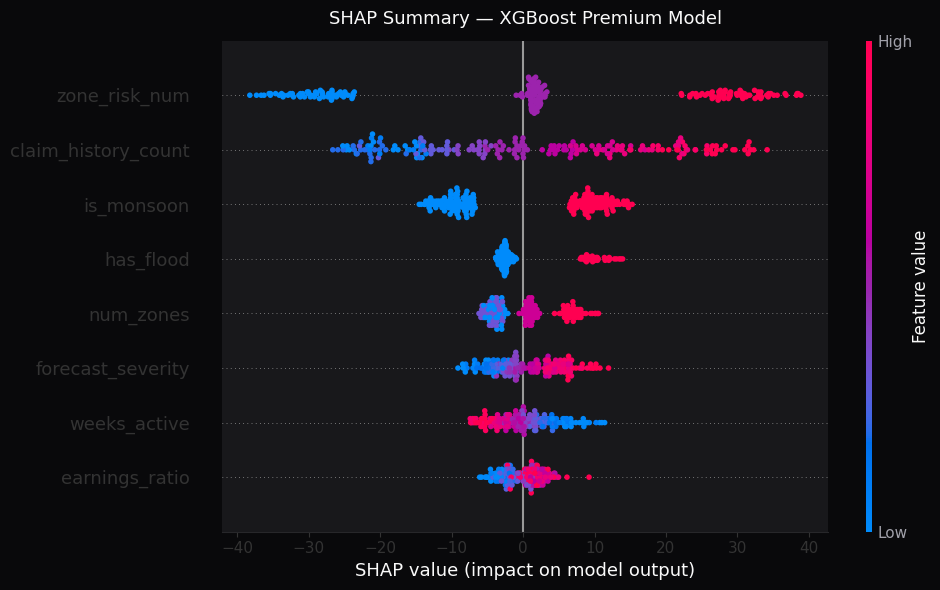

In [12]:
brand_style()
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, shap_test_sample,
                  plot_type='dot', show=False, plot_size=None)
plt.title('SHAP Summary — XGBoost Premium Model', color=TEXT, pad=12)
plt.tight_layout()
plt.show()

## 13. SHAP Waterfall — Arjun Kumar
Shows exactly which features push Arjun's premium above or below the base value. The claim_history_count bar is annotated — its negative value is a model interaction effect at the penalty threshold, not a real premium reduction.

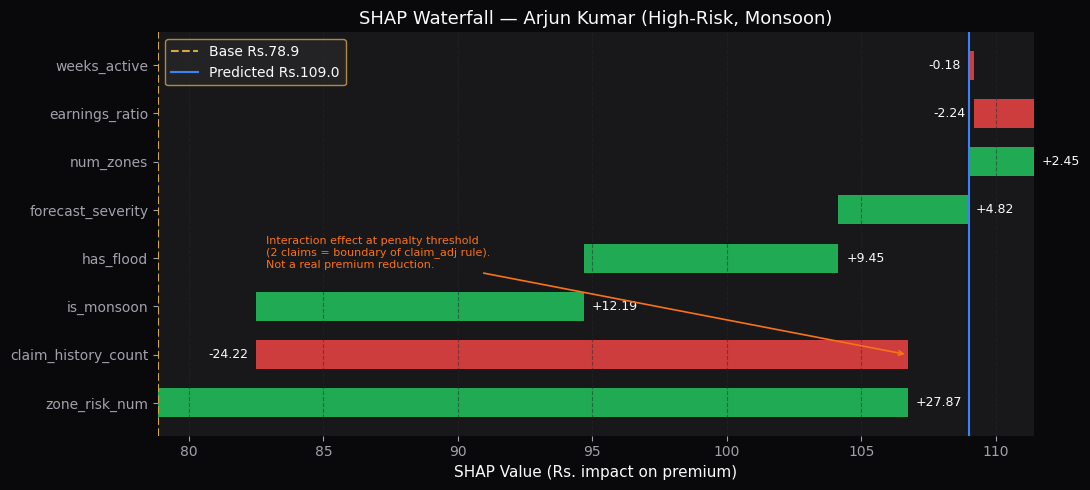

In [13]:
brand_style()
arjun = pd.DataFrame([{
    'zone_risk_num': 3, 'is_monsoon': 1, 'claim_history_count': 2,
    'forecast_severity': 0.7, 'earnings_ratio': 3200/5000,
    'weeks_active': 33, 'has_flood': 1, 'num_zones': 3,
}])
sv       = xgb_explainer.shap_values(arjun)[0]
base_val = xgb_explainer.expected_value
pred     = base_val + sv.sum()

sorted_pairs = sorted(zip(sv, arjun.columns.tolist()),
                      key=lambda x: abs(x[0]), reverse=True)
bars_data, cumulative = [], base_val
for v, name in sorted_pairs:
    bars_data.append((cumulative, v, name))
    cumulative += v

fig, ax = plt.subplots(figsize=(11, 5))
for i, (start, width, name) in enumerate(bars_data):
    ax.barh(i, width, left=start, color=GREEN if width>0 else RED,
            alpha=0.85, height=0.6, edgecolor='none')
    ax.text(start+width+(0.3 if width>0 else -0.3), i,
            f'{width:+.2f}', va='center',
            ha='left' if width>0 else 'right', color=TEXT, fontsize=9)

ax.axvline(base_val, color=AMBER, lw=1.5, linestyle='--',
           label=f'Base Rs.{base_val:.1f}')
ax.axvline(pred, color=BLUE, lw=1.5,
           label=f'Predicted Rs.{pred:.1f}')
ax.set_yticks(range(len(bars_data)))
ax.set_yticklabels([n for _,_,n in bars_data])
ax.set_xlabel('SHAP Value (Rs. impact on premium)')
ax.set_title('SHAP Waterfall — Arjun Kumar (High-Risk, Monsoon)')
ax.legend()
ax.grid(axis='x')
ax.spines[['top','right','left','bottom']].set_visible(False)

# Annotate the threshold interaction on claim_history_count
claim_idx = [i for i,(s,v,n) in enumerate(bars_data) if n=='claim_history_count']
if claim_idx:
    ci = claim_idx[0]
    ax.annotate(
        'Interaction effect at penalty threshold\n'
        '(2 claims = boundary of claim_adj rule).\n'
        'Not a real premium reduction.',
        xy=(bars_data[ci][0], ci),
        xytext=(base_val+4, ci+1.8),
        color=ORANGE, fontsize=8,
        arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2)
    )

plt.tight_layout()
plt.show()

## 14. SHAP — IsolationForest Fraud Signals
Average SHAP contribution of each feature across the 20 fraud samples. Shows which signals the model relies on most.

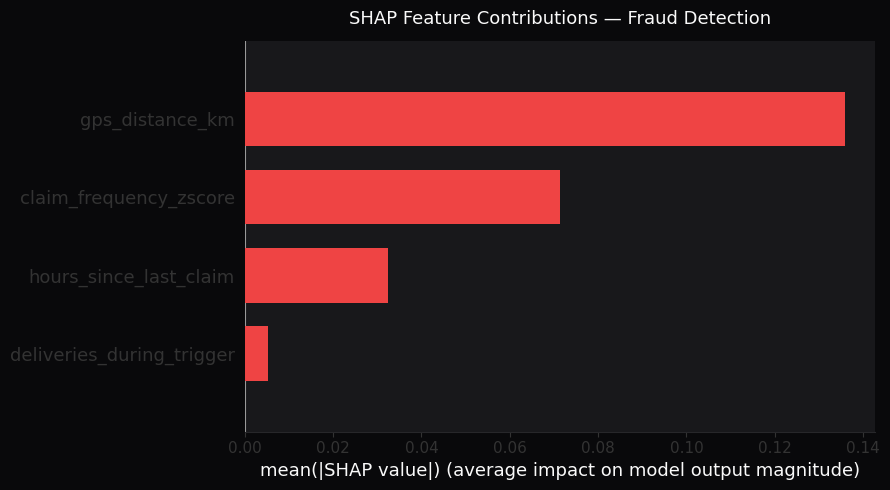

In [14]:
brand_style()
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values_if, fraud_sample,
                  plot_type='bar', show=False, plot_size=None, color=RED)
plt.title('SHAP Feature Contributions — Fraud Detection', color=TEXT, pad=12)
plt.tight_layout()
plt.show()

## 15. Risk Calendar
Rule-based zone risk scoring for 30 days. Not an ML model. Scores are fully deterministic — same zone and date always return the same score.

In [15]:
def risk_calendar(zone, year=2026, month=11):
    """
    Replicates the app's /api/ml/risk-calendar endpoint.
    Pure rule-based — no ML involved despite the /ml/ path.
    """
    profile = ZONES.get(zone, ZONES['Velachery'])
    base    = {'high':0.25, 'standard':0.12, 'low':0.05}[profile['risk']]
    days    = []
    for d in range(1, 31):
        try:
            dt = datetime(year, month, d)
        except ValueError:
            break
        score = base
        if is_monsoon(dt.month): score += 0.20
        if dt.weekday() >= 5:    score += 0.05
        score = min(score + hash(f'{zone}{dt.date()}') % 1000 / 10000, 1.0)
        triggers = []
        if score >= 0.75: triggers.append('power_outage')
        if score >= 0.60: triggers.append('traffic_disruption')
        if score >= 0.50: triggers.append('waterlogging')
        if score >= 0.30: triggers.append('heavy_rainfall')
        days.append({'date': dt, 'score': round(score,3), 'triggers': triggers})
    return days

cal = risk_calendar('Velachery')
for d in cal[:5]:
    print(f"{d['date'].strftime('%b %d')}  score={d['score']:.3f}  "
          f"triggers={d['triggers']}")
print()
print('Scores are deterministic. No ML model is involved.')
print('A true ML forecast would require historical trigger data per zone')
print('and a trained time-series model.')

Nov 01  score=0.512  triggers=['waterlogging', 'heavy_rainfall']
Nov 02  score=0.536  triggers=['waterlogging', 'heavy_rainfall']
Nov 03  score=0.508  triggers=['waterlogging', 'heavy_rainfall']
Nov 04  score=0.473  triggers=['heavy_rainfall']
Nov 05  score=0.470  triggers=['heavy_rainfall']

Scores are deterministic. No ML model is involved.
A true ML forecast would require historical trigger data per zone
and a trained time-series model.


## 16. Risk Calendar Heatmap
Day-by-day risk scores for six zones. High-risk zones are consistently orange/red, low-risk stay green.

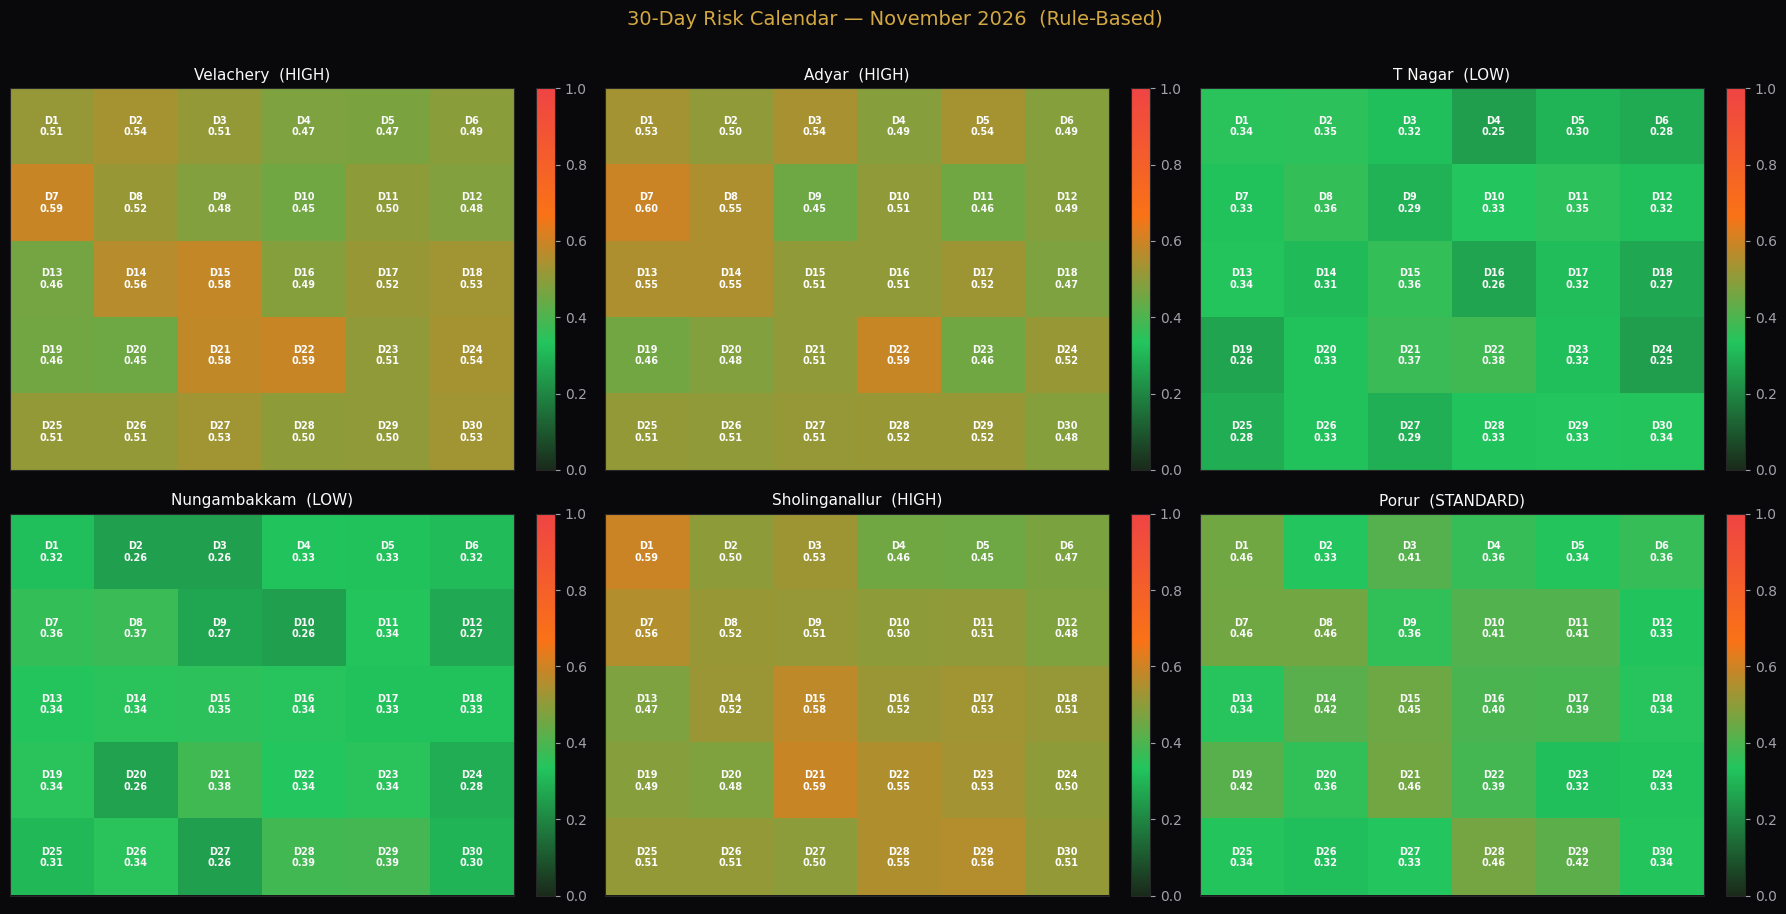

In [16]:
brand_style()
selected = ['Velachery','Adyar','T Nagar','Nungambakkam','Sholinganallur','Porur']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('30-Day Risk Calendar — November 2026  (Rule-Based)',
             color=AMBER, fontsize=14, y=1.01)

risk_cmap = mcolors.LinearSegmentedColormap.from_list(
    'delisure', ['#1a2a1a', GREEN, ORANGE, RED], N=256)

for ax, zone in zip(axes.flat, selected):
    cal        = risk_calendar(zone)
    scores_arr = np.array([d['score'] for d in cal])
    padded     = np.full(30, np.nan)
    padded[:len(scores_arr)] = scores_arr
    grid = padded.reshape(5, 6)
    im   = ax.imshow(grid, cmap=risk_cmap, vmin=0, vmax=1, aspect='auto')
    for i in range(5):
        for j in range(6):
            idx = i*6+j
            if idx < len(scores_arr):
                s = scores_arr[idx]
                ax.text(j, i, f'D{idx+1}\n{s:.2f}', ha='center', va='center',
                        color='white' if s>0.5 else TEXT, fontsize=7, fontweight='bold')
    ax.set_title(f'{zone}  ({ZONES[zone]["risk"].upper()})', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 17. All-Zone Risk Comparison
Average November risk score for all 16 zones, sorted and color-coded by tier.

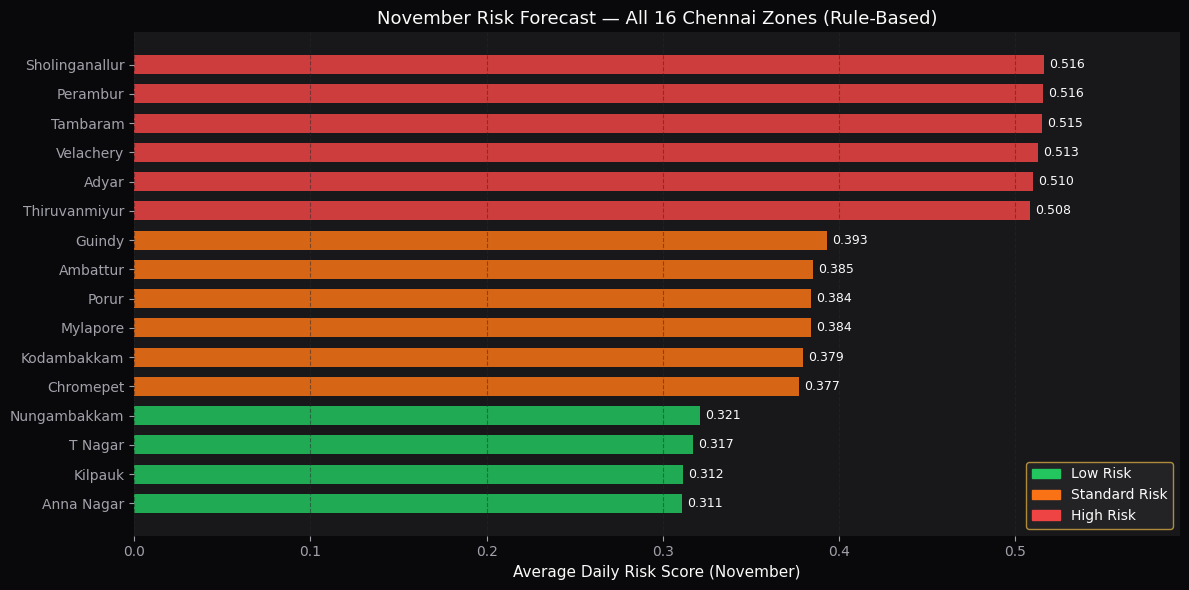

In [17]:
brand_style()
zone_avg_risk = {z: np.mean([d['score'] for d in risk_calendar(z)]) for z in ZONES}
sorted_zones  = sorted(zone_avg_risk.items(), key=lambda x: x[1])
z_names  = [z[0] for z in sorted_zones]
z_scores = [z[1] for z in sorted_zones]
z_colors = [RED if ZONES[z]['risk']=='high' else
             (ORANGE if ZONES[z]['risk']=='standard' else GREEN) for z in z_names]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(z_names, z_scores, color=z_colors, alpha=0.85, edgecolor='none', height=0.65)
for bar, val in zip(bars, z_scores):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', color=TEXT, fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color=GREEN,  label='Low Risk'),
    mpatches.Patch(color=ORANGE, label='Standard Risk'),
    mpatches.Patch(color=RED,    label='High Risk'),
], loc='lower right')
ax.set_xlabel('Average Daily Risk Score (November)')
ax.set_title('November Risk Forecast — All 16 Chennai Zones (Rule-Based)')
ax.set_xlim(0, max(z_scores)*1.15)
ax.grid(axis='x')
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.show()

## 18. End-to-End Payout Simulation
Runs a full trigger for Velachery workers: computes time-window payout, runs fraud check, and prints the recommendation. Uses the app's exact formula.

In [18]:
TIME_WINDOWS = [
    {'name':'Morning',     'start':7,   'end':11,   'mult':0.8, 'rate':0.40},
    {'name':'Lunch Peak',  'start':11,  'end':15,   'mult':1.2, 'rate':0.60},
    {'name':'Afternoon',   'start':15,  'end':19,   'mult':0.7, 'rate':0.40},
    {'name':'Dinner Peak', 'start':19,  'end':22.5, 'mult':1.5, 'rate':0.70},
]

def calc_payout(weekly_earnings, weekly_hours, t_start, t_end):
    hourly = weekly_earnings / weekly_hours
    total, breakdown = 0.0, []
    for w in TIME_WINDOWS:
        ov_start = max(t_start, w['start'])
        ov_end   = min(t_end,   w['end'])
        if ov_end > ov_start:
            hours  = ov_end - ov_start
            amount = hourly * w['mult'] * w['rate'] * hours
            total += amount
            breakdown.append({'window': w['name'], 'hours': hours, 'amount': amount})
    return min(total, weekly_earnings), breakdown

print('='*62)
print('  TRIGGER: Heavy Rainfall — Velachery — 18:00 to 21:00')
print('  Intensity: 18 mm/hr  (threshold >= 14 mm/hr)')
print('='*62)

for w in SEED_WORKERS:
    if 'Velachery' not in w['zones']:
        continue
    payout, breakdown = calc_payout(
        w['avg_weekly_earnings'], w['avg_active_hours_per_week'], 18, 21)
    fraud_row = pd.Series({
        'gps_distance_km': 2.1, 'deliveries_during_trigger': 0,
        'claim_frequency_zscore': 0.5, 'hours_since_last_claim': 96,
    })
    f_score, rec, _ = combined_fraud_score(fraud_row)
    print(f"\n  Worker     : {w['name']} ({w['risk_tier']})")
    print(f"  Payout     : Rs.{payout:.2f}")
    for b in breakdown:
        print(f"    {b['window']:<14} {b['hours']:.1f}h -> Rs.{b['amount']:.2f}")
    print(f"  Fraud Score: {f_score:.3f}  |  {rec.upper()}")

print('\n' + '='*62)

  TRIGGER: Heavy Rainfall — Velachery — 18:00 to 21:00
  Intensity: 18 mm/hr  (threshold >= 14 mm/hr)

  Worker     : Arjun Kumar (high)
  Payout     : Rs.181.33
    Afternoon      1.0h -> Rs.21.33
    Dinner Peak    2.0h -> Rs.160.00
  Fraud Score: 0.151  |  APPROVE

  Worker     : Ravi Shankar (high)
  Payout     : Rs.185.11
    Afternoon      1.0h -> Rs.21.78
    Dinner Peak    2.0h -> Rs.163.33
  Fraud Score: 0.151  |  APPROVE



## 19. Summary Dashboard
One-page overview: key metrics as cards, predicted vs actual scatter, top 8 risk zones.

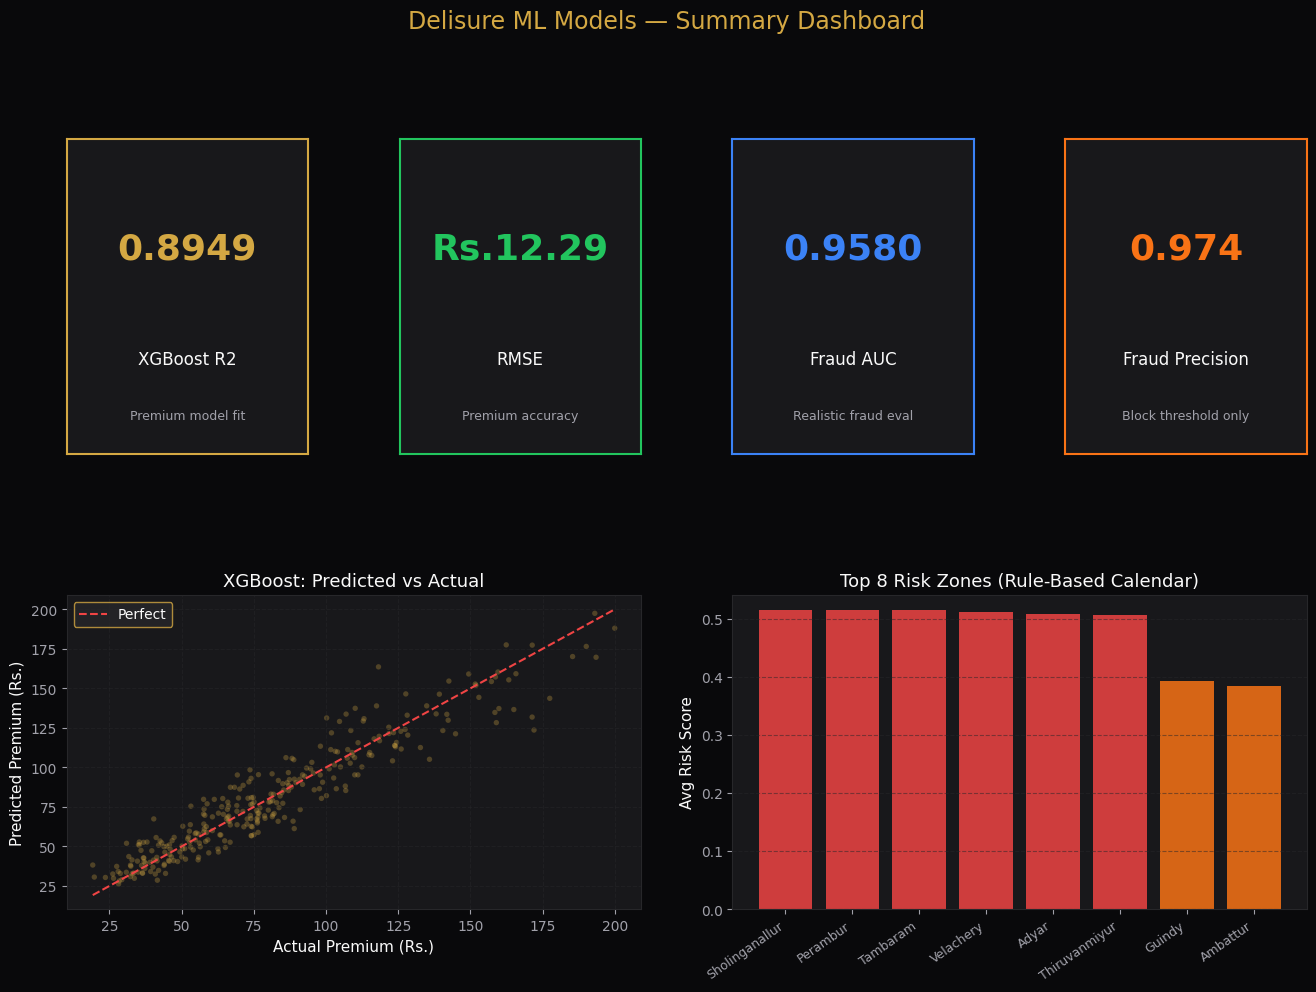

In [19]:
brand_style()
fraud_precision = cm[1,1] / (cm[0,1] + cm[1,1] + 1e-8)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Delisure ML Models — Summary Dashboard', fontsize=17, color=AMBER, y=1.01)
gs  = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.38)

metrics = [
    ('XGBoost R2',     f'{r2:.4f}',          AMBER,  'Premium model fit'),
    ('RMSE',           f'Rs.{rmse:.2f}',      GREEN,  'Premium accuracy'),
    ('Fraud AUC',      f'{auc:.4f}',          BLUE,   'Realistic fraud eval'),
    ('Fraud Precision',f'{fraud_precision:.3f}', ORANGE,'Block threshold only'),
]
for idx, (title, value, color, subtitle) in enumerate(metrics):
    ax = fig.add_subplot(gs[0, idx])
    ax.set_facecolor(CARD)
    ax.text(0.5, 0.65, value,    ha='center', va='center', fontsize=26,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.30, title,    ha='center', va='center', fontsize=12,
            color=TEXT, transform=ax.transAxes)
    ax.text(0.5, 0.12, subtitle, ha='center', va='center', fontsize=9,
            color='#A1A1AA', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(1.5)
    ax.set_xticks([]); ax.set_yticks([])

ax2 = fig.add_subplot(gs[1, :2])
ax2.scatter(y_test[:300], y_pred[:300], alpha=0.3, color=AMBER, s=15, edgecolors='none')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax2.plot([mn,mx],[mn,mx], color=RED, lw=1.5, linestyle='--', label='Perfect')
ax2.set_xlabel('Actual Premium (Rs.)')
ax2.set_ylabel('Predicted Premium (Rs.)')
ax2.set_title('XGBoost: Predicted vs Actual')
ax2.legend(); ax2.grid(True)

ax3 = fig.add_subplot(gs[1, 2:])
top8    = sorted(zone_avg_risk.items(), key=lambda x: x[1], reverse=True)[:8]
tz      = [z[0] for z in top8]
ts      = [z[1] for z in top8]
tc      = [RED if ZONES[z]['risk']=='high' else
            (ORANGE if ZONES[z]['risk']=='standard' else GREEN) for z in tz]
ax3.bar(range(len(tz)), ts, color=tc, alpha=0.85, edgecolor='none')
ax3.set_xticks(range(len(tz)))
ax3.set_xticklabels(tz, rotation=35, ha='right', fontsize=9)
ax3.set_ylabel('Avg Risk Score')
ax3.set_title('Top 8 Risk Zones (Rule-Based Calendar)')
ax3.grid(axis='y')

plt.savefig('delisure_summary.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
